In [1]:
# Example 1. ARIMA
import argparse
from pathlib import Path

import numpy as np
import torch
from torch.utils.data import DataLoader, Subset

from src.loader   import load_all
from src.features import (
    engineer, MultiSiteScaler,
    TARGET_FEAT_COLS, NEIGHBOR_FEAT_COLS,
)
from src.dataset  import SolarDataset, time_split
from src.model    import SolarGRU
from src.train    import train, predict
from src.metrics  import evaluate_all, print_results
# ── Config ────────────────────────────────────────────────────────────────────
DATA_DIR   =  "data"
TARGET_ID  = "41.93"          # substring that identifies the target CSV
HORIZONS   = [1, 6, 24]       # forecast horizons in hours
LOOKBACK   = 24               # lookback window in hours
BATCH_SIZE = 64
EPOCHS     = 100
PATIENCE   = 15
LR         = 1e-3
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
SEED       = 42

# ── 1. Load ──────────────────────────────────────────────────────────────
target_raw, neighbor_raws = load_all(DATA_DIR, TARGET_ID)

# ── 2. Feature engineering ───────────────────────────────────────────────
target_df    = engineer(target_raw)
neighbor_dfs = [engineer(df) for df in neighbor_raws]

T = len(target_df)
train_idx, val_idx, test_idx = time_split(T)
print(f"[split] train={len(train_idx)} | val={len(val_idx)} | test={len(test_idx)} rows")

# ── 3. Scale ─────────────────────────────────────────────────────────────
scaler = MultiSiteScaler()

# Fit on train portion only
target_train = target_df.iloc[train_idx]
scaler.fit_transform_target(target_train, TARGET_FEAT_COLS)   # fit only

# Apply to full series
target_scaled = scaler.transform_target(target_df, TARGET_FEAT_COLS)

neighbor_scaled_list = []
for i, n_df in enumerate(neighbor_dfs):
    n_train = n_df.iloc[train_idx]
    scaler.fit_transform_neighbor(n_train, NEIGHBOR_FEAT_COLS, i)
    neighbor_scaled_list.append(scaler.transform_neighbor(n_df, NEIGHBOR_FEAT_COLS, i))

# ── 4. Arrays ────────────────────────────────────────────────────────────
target_arr    = target_scaled[TARGET_FEAT_COLS].values
neighbor_arrs = [df[NEIGHBOR_FEAT_COLS].values for df in neighbor_scaled_list]
kt_raw        = target_df["kt"].values
clearsky_raw  = target_raw["Clearsky GHI"].values

# ── 5. Dataset & loaders ─────────────────────────────────────────────────
full_ds = SolarDataset(
    target_arr, neighbor_arrs, kt_raw, clearsky_raw, horizons=HORIZONS,
)

[loader] Target   : 401390_41.93_2.26  (105120 rows, 3 file(s))
[loader] Neighbor : 374878_41.13_1.26  (105120 rows, 3 file(s))
[loader] Neighbor : 399338_41.37_2.18  (105120 rows, 3 file(s))
[loader] Neighbor : 415947_41.97_2.82  (105120 rows, 3 file(s))
[loader] Neighbor : 357488_41.61_0.62  (105120 rows, 3 file(s))
[split] train=73584 | val=15768 | test=15768 rows


In [20]:
full_ds.kt

array([0., 0., 0., ..., 0., 0., 0.], shape=(105120,), dtype=float32)

In [4]:
import pandas as pd


# extract real GDP variable for analysis
y = np.array(full_ds.kt[:100000])

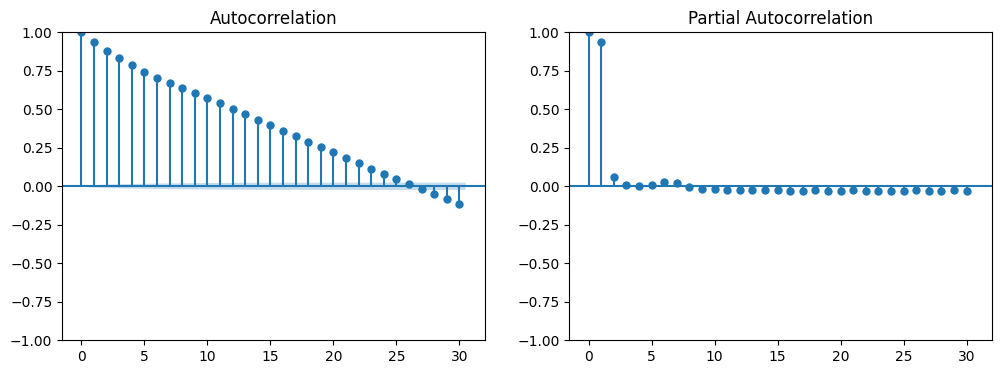

In [5]:
#ACF / PACF diagnostics
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, ax = plt.subplots(1,2, figsize=(12,4))
plot_acf(y, ax=ax[0], lags=30)
plot_pacf(y, ax=ax[1], lags=30)
plt.show()

# this suggests ARIMA(1,0,1)
# ACF decreases steadily
# PACF shows spike at lag 1 - AR(1) candidate

In [24]:
y.head(100)

,0
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
...,...
95,0.0
96,0.0
97,0.0
98,0.0


/Users/dalmau/Documents/UB-2025/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/dalmau/Documents/UB-2025/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/dalmau/Documents/UB-2025/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


TypeError: 'int' object is not subscriptable

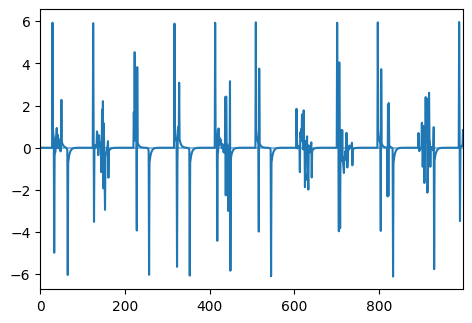

In [27]:
# FIT ARIMA
from statsmodels.tsa.arima.model import ARIMA


y_diff = y.diff().dropna()  # Just simple differencing

# Fit model on differenced data
model = ARIMA(y_diff, order=(1,0,1))  # d=0 since you already differenced
result = model.fit()
# Diagnostics
result.plot_diagnostics(figsize=(12,8))
plt.show()

                               SARIMAX Results                                
Dep. Variable:                      0   No. Observations:                 1000
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 418.434
Date:                Fri, 17 Apr 2026   AIC                           -830.868
Time:                        17:41:54   BIC                           -816.148
Sample:                             0   HQIC                          -825.273
                               - 1000                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6413      0.067      9.561      0.000       0.510       0.773
ma.L1         -0.7575      0.059    -12.943      0.000      -0.872      -0.643
sigma2         0.0253      0.000     71.769      0.0

TypeError: 'int' object is not subscriptable

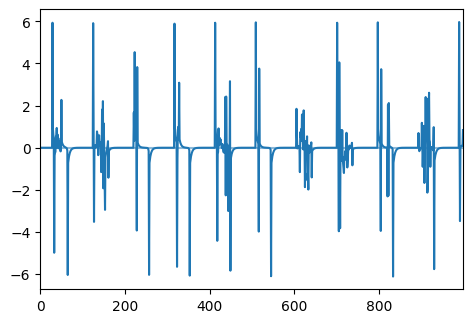

In [30]:
# let the model diffentiate by itself
from statsmodels.tsa.arima.model import ARIMA

model2 = ARIMA(y.dropna(), order=(1,1,1))
result2 = model2.fit()

print(result2.summary())

# Diagnostics
result2.plot_diagnostics(figsize=(12,8))
plt.show()

In [ ]:
##############################################################

In [22]:
# Example 2. SARIMA with real weather data

import statsmodels.api as sm

data = sm.datasets.co2.load_pandas().data
y = pd.Series(np.array(full_ds.kt[:1000]))

y_diff = pd.Series(y).diff().dropna()

<Axes: >

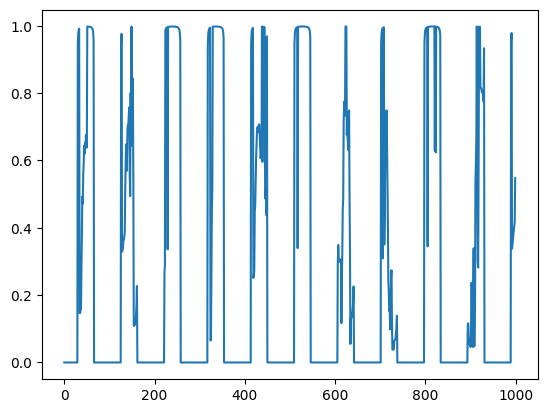

In [23]:
y.plot()

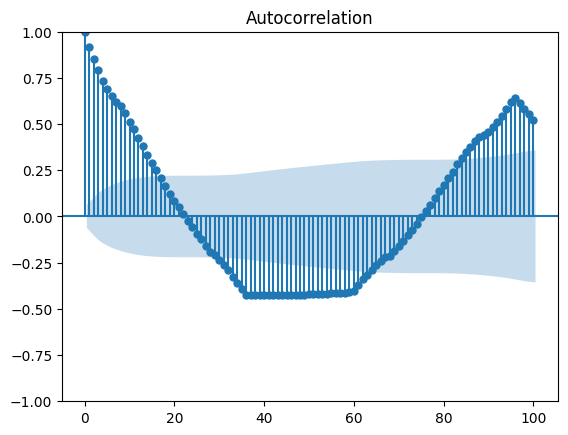

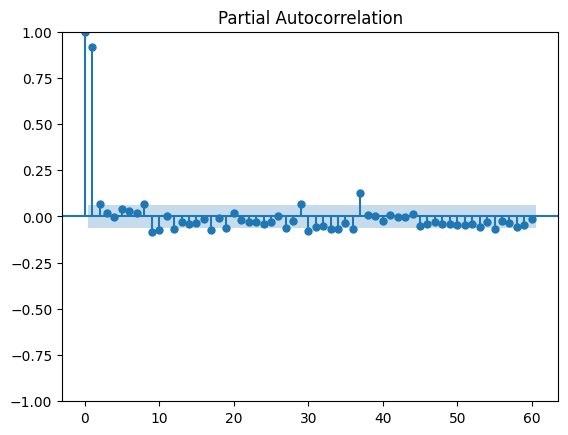

In [12]:
# ACF, PACF
plot_acf(y, lags=100)
plot_pacf(y, lags=60)
plt.show()

In [13]:
# Strong spikes at lag 12, 24 → seasonality

# Slow decaying ACF -  non-stationary

# Apply seasonal differencing!

In [26]:
# Fit SARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(y,
                order=(1,1,1),
                seasonal_order=(1,1,1,96))

result = model.fit()
print(result.summary())

                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                 1000
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 96)   Log Likelihood                 535.367
Date:                            Fri, 17 Apr 2026   AIC                          -1060.734
Time:                                    17:51:25   BIC                          -1036.706
Sample:                                         0   HQIC                         -1051.557
                                           - 1000                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8162      0.015     54.459      0.000       0.787       0.846
ma.L1         -0.9924      0.007   

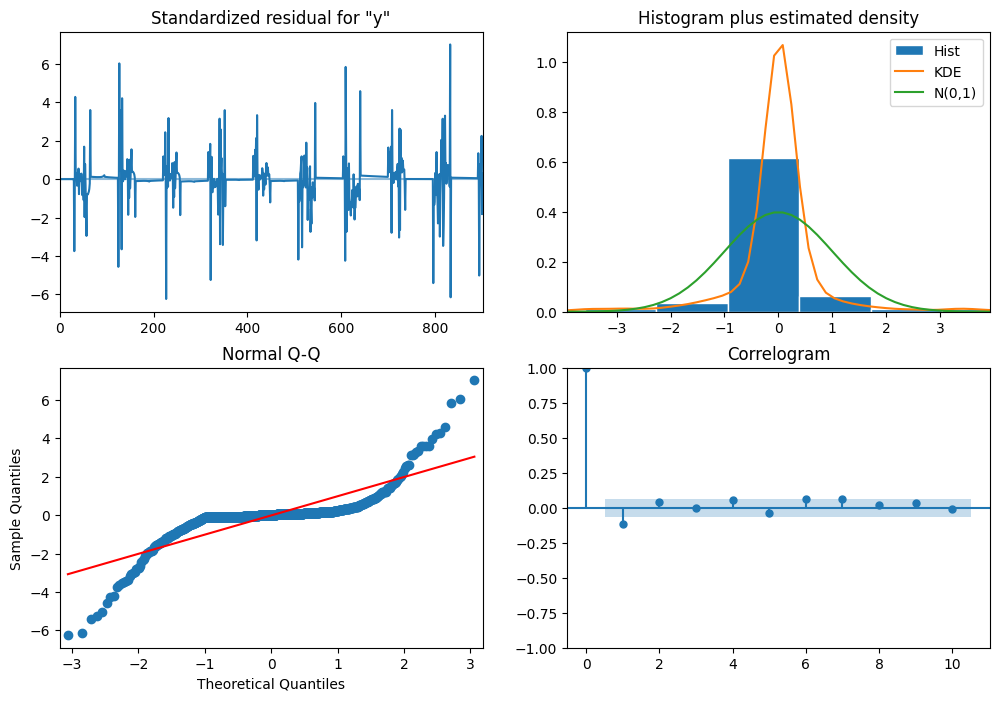

In [27]:
# Diagnostics
result.plot_diagnostics(figsize=(12,8))
plt.show()

In [43]:
# Things to look for:
# Residuals ≈ white noise
# Q-Q plot ≈ normal
# No structure in ACF

In [ ]:
###################################################################

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  200
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -286.933
Date:                Fri, 17 Apr 2026   AIC                            581.866
Time:                        17:51:57   BIC                            595.060
Sample:                             0   HQIC                           587.205
                                - 200                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0118      0.044      0.268      0.789      -0.075       0.098
ar.L1          0.3354      0.213      1.576      0.115      -0.082       0.753
ma.L1         -0.5970      0.183     -3.259      0.0

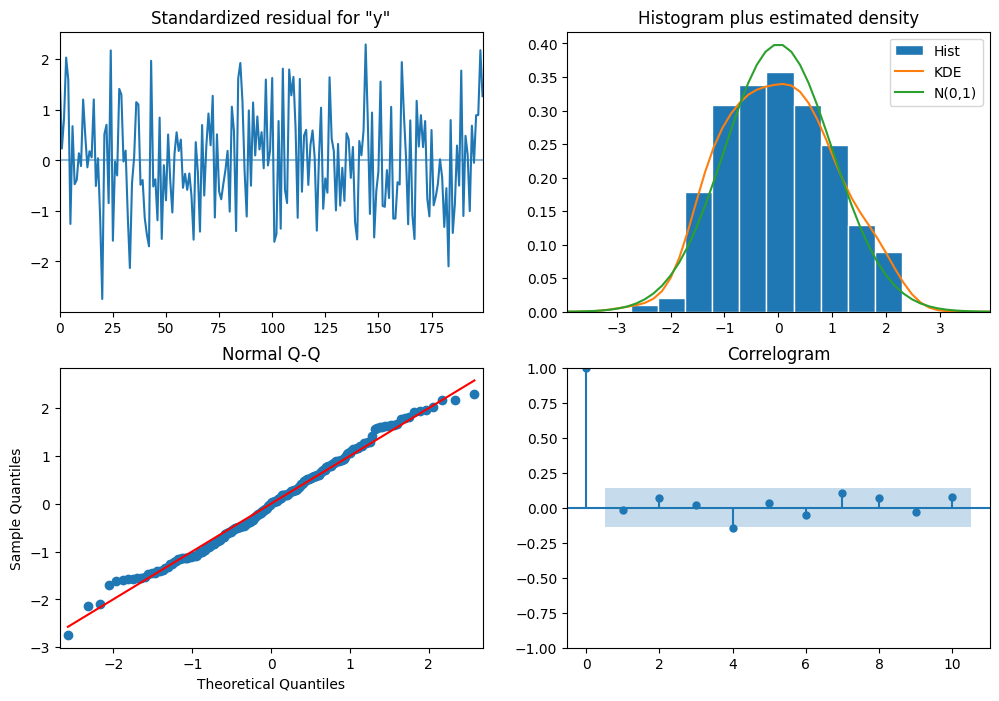

In [28]:
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA

def fractional_noise(d, n):

    w = np.random.normal(size=n)
    x = np.zeros(n)
    
    # compute coefficients recursively
    coef = np.zeros(n)
    coef[0] = 1
    
    for k in range(1, n):
        coef[k] = coef[k-1] * (k-1-d) / k
    
    # apply convolution-like sum
    for t in range(n):
        x[t] = np.dot(coef[:t+1], w[t::-1])
    
    return x

np.random.seed(0)
n = 200
d = 0.3

y = fractional_noise(d, n)
y = pd.Series(y)

# We use ARIMA, as FARIMA is not directly supported by statsmodel
model = ARIMA(y, order=(1,0,1))
result = model.fit()

print(result.summary())

# Diagnostics
result.plot_diagnostics(figsize=(12,8))
plt.show()

In [29]:
forecast = result.forecast(steps=10)
print(forecast)

200   -0.556312
201   -0.178737
202   -0.052088
203   -0.009606
204    0.004644
205    0.009423
206    0.011027
207    0.011564
208    0.011745
209    0.011805
Name: predicted_mean, dtype: float64


In [18]:
# Final diagnostics:

# ARIMA:
# ACF: exponential decay
# PACF: sharp cutoff
# Residuals: white noise
    
# SARIMA:
# ACF: spikes at seasonal lags (e.g., 12, 24)
# After seasonal differencing - cleaner structure

# FARIMA:
# ACF: hyperbolic (slow) decay
# Even large lags remain significant
# Needs fractional differencing
